In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [46]:
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")


In [47]:
print(train_df.head())
print(train_df.shape)


   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [48]:
X = train_df.iloc[:, 1:].values
y = train_df.iloc[:, 0].values  

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train = X_train.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)

X_train = X_train / 255.0
X_val = X_val / 255.0

In [55]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
model.add(BatchNormalization())

model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.30))

model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.30))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

c:\Users\praga\OneDrive\Documents\new\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    min_delta=0.001,
    restore_best_weights=True
)

from tensorflow.keras.callbacks import Callback

class CustomStop(Callback):

    def on_epoch_end(self, epoch, logs=None):

        val_loss = logs.get('val_loss')

        if val_loss < 0.08:
            print("\nValidation loss reached below 8%")
            self.model.stop_training = True


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 437,866 (1.67 MB)

 Trainable params: 437,226 (1.67 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.9258 - loss: 0.2027 - val_accuracy: 0.9287 - val_loss: 0.2067
Epoch 2/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.9278 - loss: 0.1973 - val_accuracy: 0.9273 - val_loss: 0.2027
Epoch 3/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9294 - loss: 0.1948 - val_accuracy: 0.9285 - val_loss: 0.1993
Epoch 4/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9314 - loss: 0.1881 - val_accuracy: 0.9252 - val_loss: 0.2077
Epoch 5/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.9327 - loss: 0.1823 - val_accuracy: 0.9304 - val_loss: 0.1992
Epoch 6/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.9358 - loss: 0.1785 - val_accuracy: 0.9307 - val_loss: 0.2048
Epoch 7/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.9360 - loss: 0.1733 - val_accuracy: 0.9365 - val_loss: 0.1906
Epoch 8/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.9381 - loss: 0.1670 - 

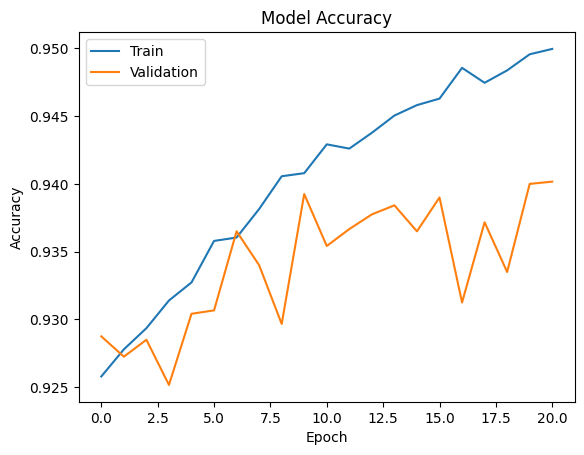

In [71]:
# TRAIN
history = model.fit(
    X_train,y_train,batch_size=64,
    epochs=40,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_val, y_val)

print("Validation Accuracy:", accuracy)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


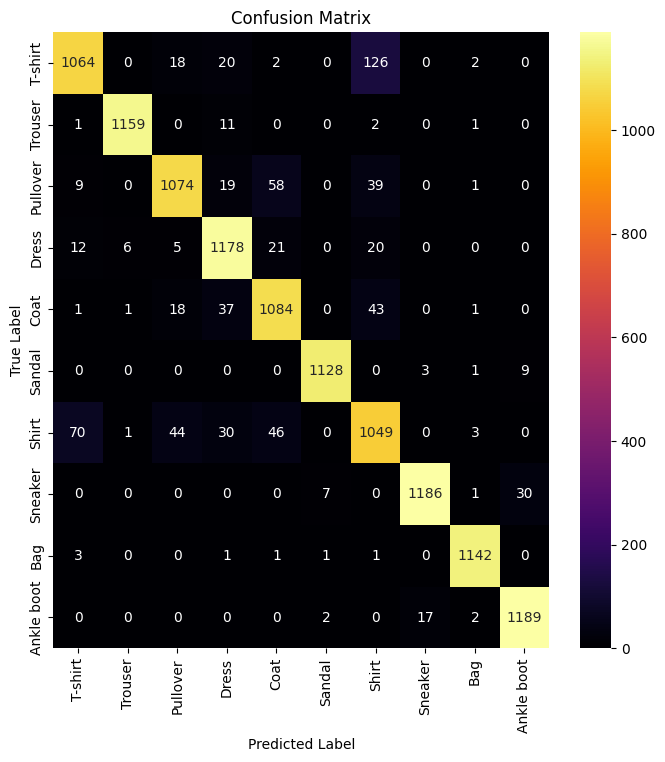

In [72]:
import seaborn as sns
predictions = model.predict(X_val)

predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_val, predicted_classes)
class_names = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
plt.figure(figsize=(8,8))

sns.heatmap(cm,annot=True,fmt='d',cmap='inferno',xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [73]:
print(classification_report(y_val, predicted_classes))
model.save("fashion_classifier.keras")
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1232
           1       0.99      0.99      0.99      1174
           2       0.93      0.90      0.91      1200
           3       0.91      0.95      0.93      1242
           4       0.89      0.91      0.90      1185
           5       0.99      0.99      0.99      1141
           6       0.82      0.84      0.83      1243
           7       0.98      0.97      0.98      1224
           8       0.99      0.99      0.99      1149
           9       0.97      0.98      0.98      1210

    accuracy                           0.94     12000
   macro avg       0.94      0.94      0.94     12000
weighted avg       0.94      0.94      0.94     12000



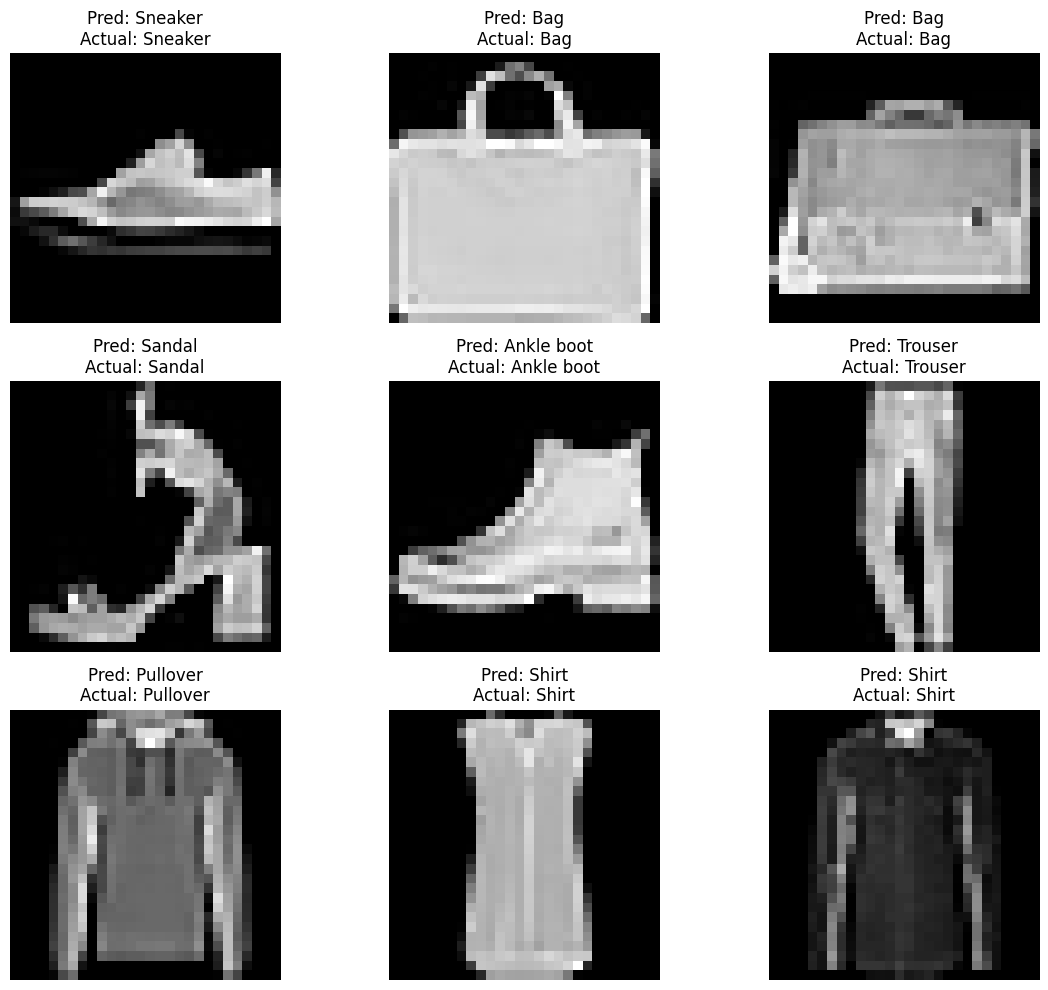

In [74]:
plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_val[i].reshape(28,28), cmap='gray')

    plt.title(
        f"Pred: {class_names[predicted_classes[i]]}\nActual: {class_names[y_val[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

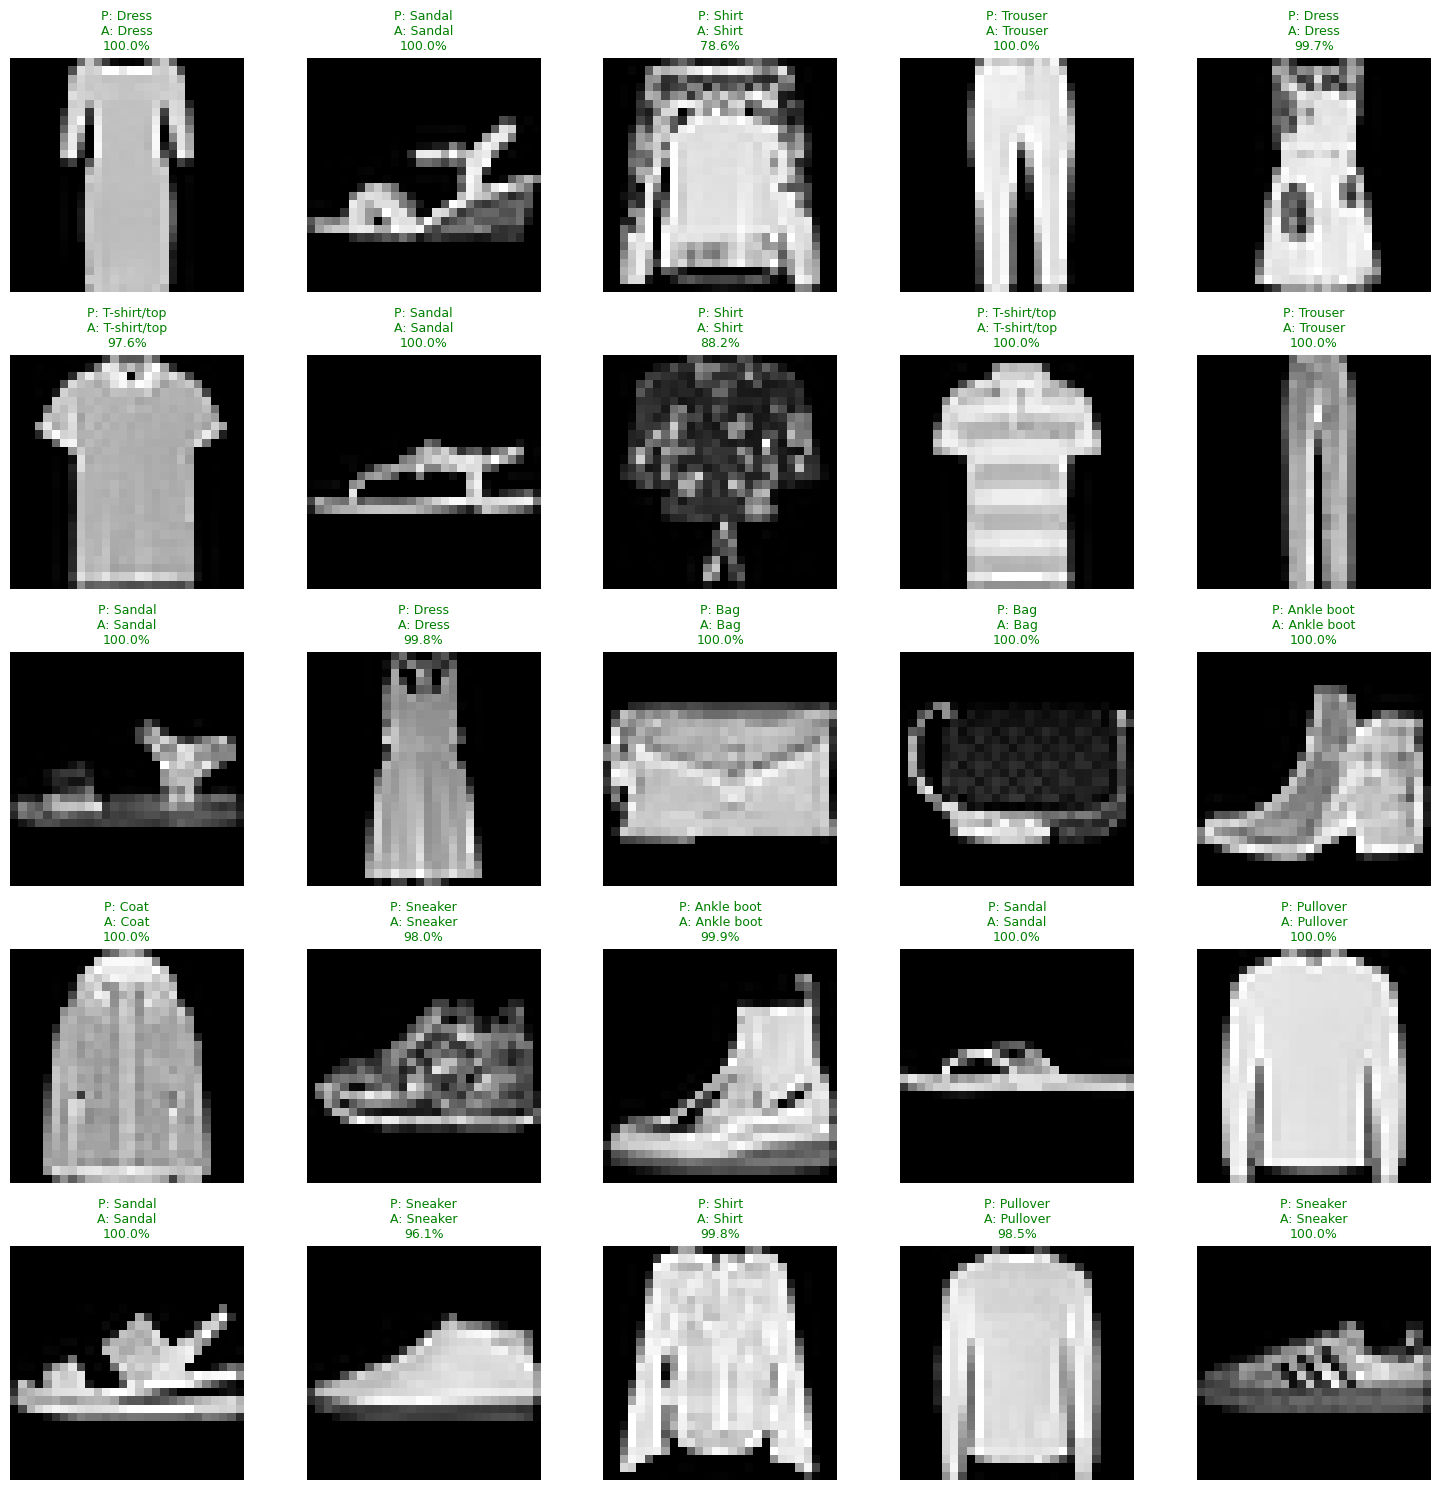

In [75]:
import random
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

random_indices = random.sample(range(len(X_val)), 25)

plt.figure(figsize=(15,15))

for i, idx in enumerate(random_indices):

    # Get image
    image = X_val[idx]

    # Predict
    prediction = model.predict(image.reshape(1,28,28,1), verbose=0)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    actual_class = y_val[idx]

    # Plot
    plt.subplot(5,5,i+1)

    plt.imshow(image.reshape(28,28), cmap='gray')

    # Green if correct else red
    color = "green" if predicted_class == actual_class else "red"

    plt.title(
        f"P: {class_names[predicted_class]}\n"
        f"A: {class_names[actual_class]}\n"
        f"{confidence:.1f}%",
        color=color,
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

Correct Predictions : 93
Wrong Predictions : 7
Accuracy on 100 Random Images: 93.00%


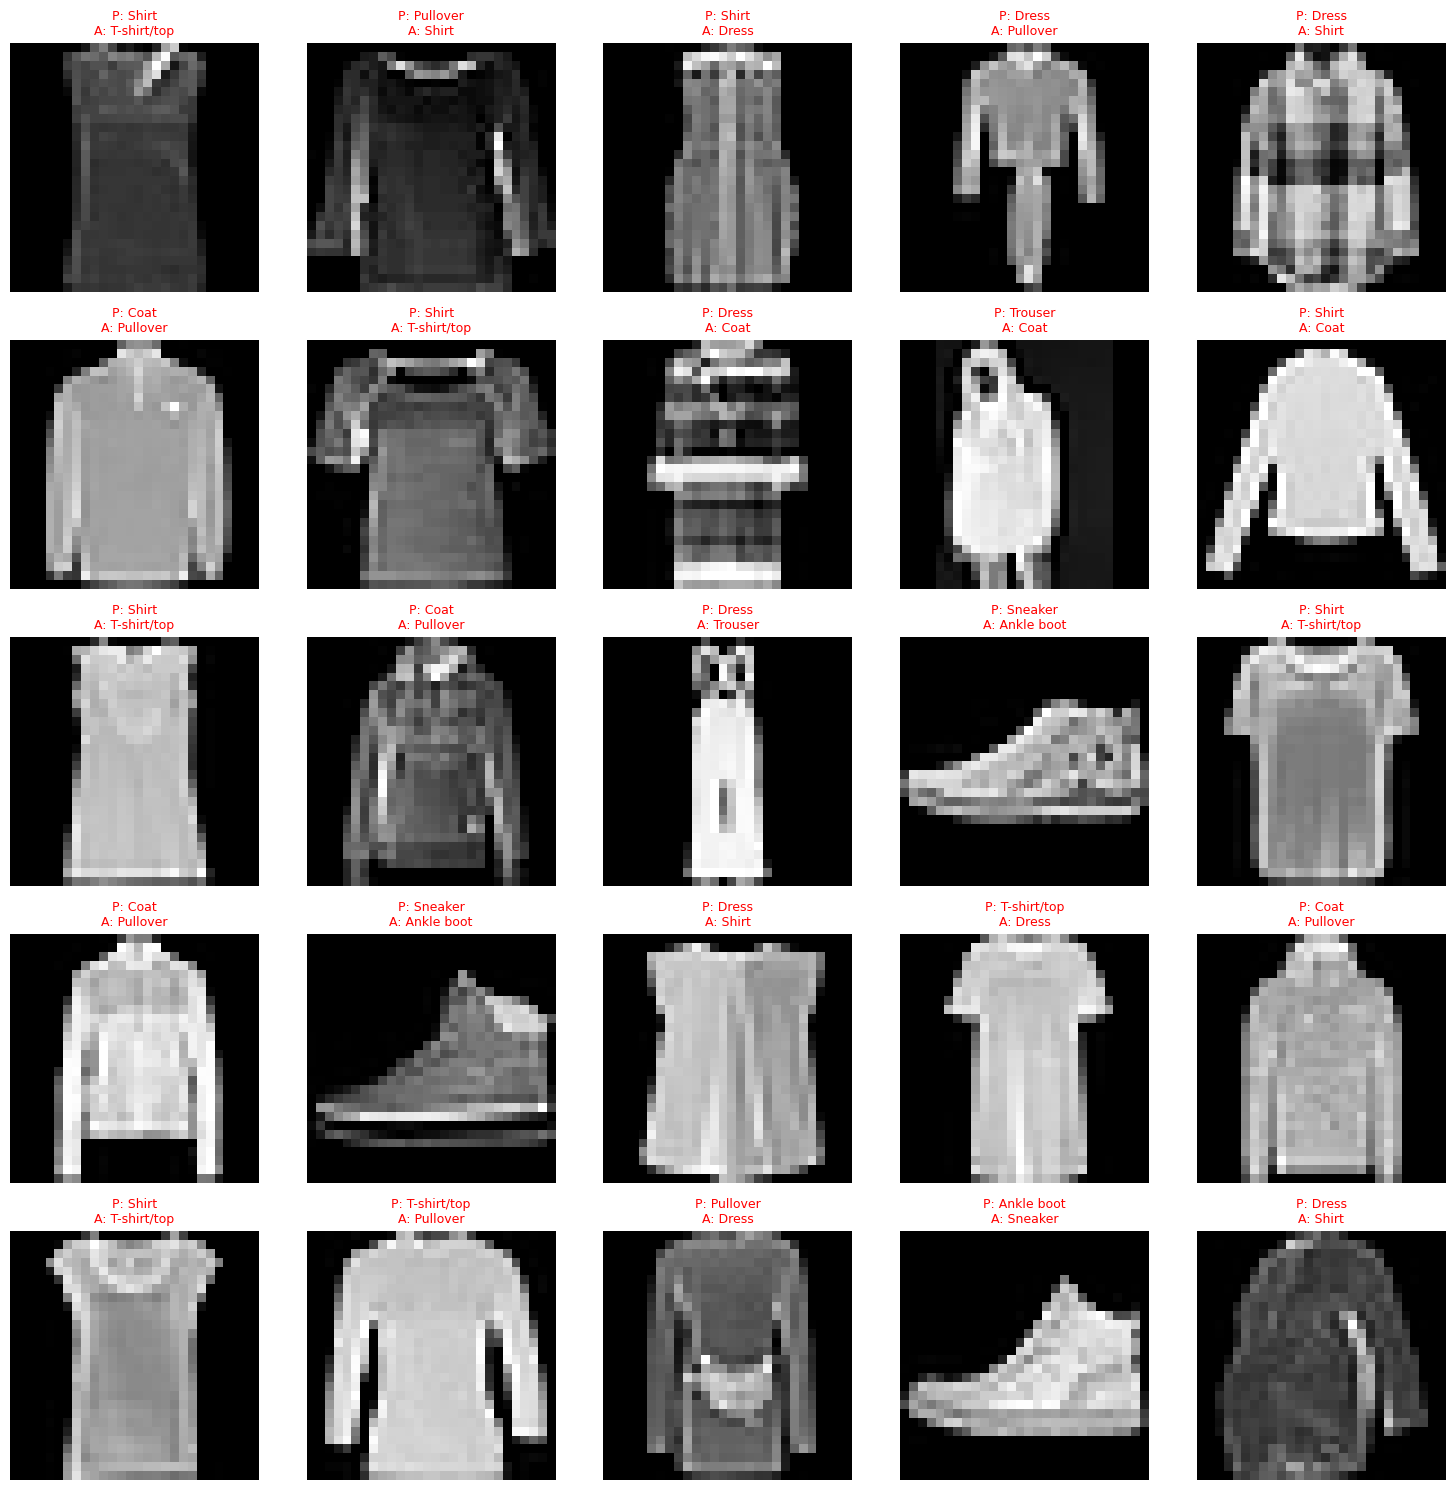

In [76]:
correct = 0
wrong = 0

for i in range(100):

    idx = random.randint(0, len(X_val)-1)

    image = X_val[idx]

    prediction = model.predict(
        image.reshape(1,28,28,1),
        verbose=0
    )

    predicted_class = np.argmax(prediction)

    actual_class = y_val[idx]

    if predicted_class == actual_class:
        correct += 1
    else:
        wrong += 1

print("Correct Predictions :", correct)
print("Wrong Predictions :", wrong)

accuracy = (correct / 100) * 100

print(f"Accuracy on 100 Random Images: {accuracy:.2f}%")

plt.figure(figsize=(15,15))

wrong_count = 0

for i in range(len(X_val)):

    image = X_val[i]

    prediction = model.predict(
        image.reshape(1,28,28,1),
        verbose=0
    )

    predicted_class = np.argmax(prediction)

    actual_class = y_val[i]

    if predicted_class != actual_class:

        wrong_count += 1

        plt.subplot(5,5,wrong_count)

        plt.imshow(image.reshape(28,28), cmap='gray')

        plt.title(
            f"P: {class_names[predicted_class]}\n"
            f"A: {class_names[actual_class]}",
            color='red',
            fontsize=9
        )

        plt.axis('off')

        if wrong_count == 25:
            break

plt.tight_layout()
plt.show()